In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/MyDrive/BUDT757/BUDT757 Group 3 Project/')
#

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Data/enron_spam_data.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 non-null  int64 
 1   Subject     33427 non-null  object
 2   Message     33345 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB
None


EDA

Dataset Shape: (33716, 5)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 non-null  int64 
 1   Subject     33427 non-null  object
 2   Message     33345 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB
None

First 5 rows:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999

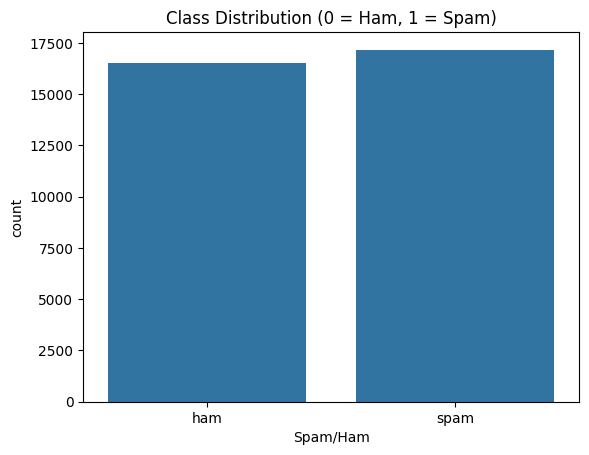

/tmp/ipython-input-519/268273875.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(class_counts[1] / len(df) * 100, 2), "%")



Class Imbalance Ratio (Spam %): 49.07 %

Missing Values:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

Summary Statistics (Character Length):
count     33716.000000
mean       1470.356211
std        4283.503264
min           1.000000
25%         308.000000
50%         675.000000
75%        1514.250000
max      228353.000000
Name: char_length, dtype: float64

Summary Statistics (Word Count):
count    33716.000000
mean       303.407551
std        851.499439
min          1.000000
25%         65.000000
50%        146.000000
75%        322.000000
max      45448.000000
Name: word_count, dtype: float64


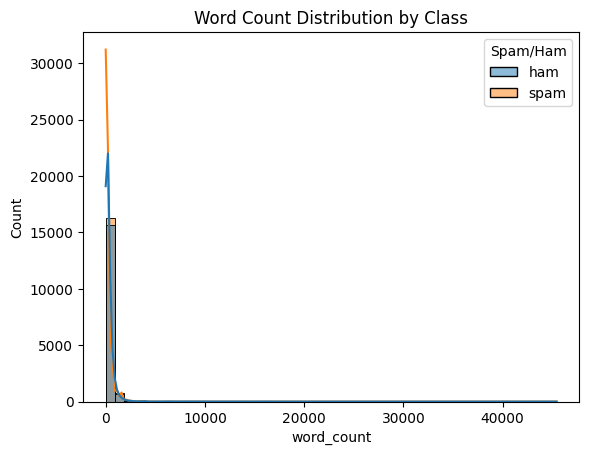


Average Word Count by Class:
Spam/Ham
ham     355.470233
spam    253.242910
Name: word_count, dtype: float64

Top 20 Most Frequent Words:
             Frequency
enron            59775
ect              35338
com              23932
company          22806
hou              17263
2001             15229
new              14366
10               14163
subject          14038
2000             13628
information      12786
00               12446
time             12121
said             11880
business         11847
gas              11501
energy           11142
http             11073
email            10249
000              10156


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# ---- Basic Structure ----
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

# ---- Class Distribution ----
print("\nClass Distribution:")
class_counts = df["Spam/Ham"].value_counts()
print(class_counts)

plt.figure()
sns.countplot(x="Spam/Ham", data=df)
plt.title("Class Distribution (0 = Ham, 1 = Spam)")
plt.show()

print("\nClass Imbalance Ratio (Spam %):",
      round(class_counts[1] / len(df) * 100, 2), "%")

# ---- Missing Values ----
print("\nMissing Values:")
print(df.isnull().sum())

# ---- Email Length Analysis ----
df["char_length"] = df["Message"].astype(str).apply(len)
df["word_count"] = df["Message"].astype(str).apply(lambda x: len(x.split()))

print("\nSummary Statistics (Character Length):")
print(df["char_length"].describe())

print("\nSummary Statistics (Word Count):")
print(df["word_count"].describe())

# ---- Length Distribution by Class ----
plt.figure()
sns.histplot(data=df, x="word_count", hue="Spam/Ham", bins=50, kde=True)
plt.title("Word Count Distribution by Class")
plt.show()

# ---- Average Length by Class ----
print("\nAverage Word Count by Class:")
print(df.groupby("Spam/Ham")["word_count"].mean())

# ---- Most Frequent Words (Quick View) ----
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=20)
X_counts = vectorizer.fit_transform(df["Message"].astype(str))

word_freq = pd.DataFrame(
    X_counts.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out(),
    columns=["Frequency"]
).sort_values(by="Frequency", ascending=False)

print("\nTop 20 Most Frequent Words:")
print(word_freq)

Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ---- Clean dataset ----
df = df.dropna(subset=["Message", "Spam/Ham"])

# ---- Text cleaning function ----
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["Message"].apply(preprocess_text)

# ---- Train-test split ----
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["Spam/Ham"],
    test_size=0.2,
    random_state=42,
    stratify=df["Spam/Ham"]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Model

In [ ]:
# ---- Build pipeline ----
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),     # unigrams + bigrams
        min_df=2,
        max_df=0.9
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

# ---- Train ----
model.fit(X_train, y_train)

# ---- Predict ----
y_pred = model.predict(X_test)

# ---- Evaluate ----
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9770580296896086
              precision    recall  f1-score   support

         ham       0.98      0.97      0.98      3299
        spam       0.97      0.98      0.98      3370

    accuracy                           0.98      6669
   macro avg       0.98      0.98      0.98      6669
weighted avg       0.98      0.98      0.98      6669



Confusion Matrix:
[[3203   96]
 [  57 3313]]


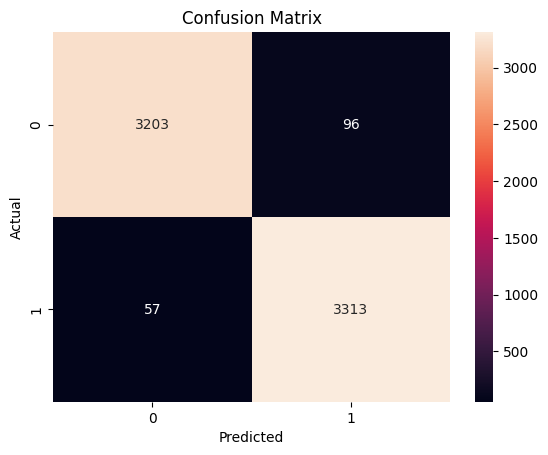

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
vectorizer = model.named_steps["tfidf"]
nb = model.named_steps["nb"]

feature_names = vectorizer.get_feature_names_out()
spam_log_probs = nb.feature_log_prob_[1]

top_spam_indices = np.argsort(spam_log_probs)[-20:]
top_spam_words = [feature_names[i] for i in top_spam_indices]

print("Top indicative spam words:")
print(top_spam_words)

Top indicative spam words:
['site', 'want', 'software', 'time', 'online', 'money', 'best', 'one', 'please', 'save', 'free', 'us', 'company', 'http www', 'get', 'email', 'www', 'click', 'com', 'http']
